# GrC Image Matting on CBIS-DDSM - Layer 1 and Layer 2 Templates

Layer 1 texture extraction at every scale, the lesion-grouped train/test split, and K-Means template learning.

Writes to Drive: `layer1_ms_lipw_{3,5,7}x{3,5,7}.npz`, `kmeans_templates.npy`, `template_meta.json`, `train_test_split.json`.

## State restoration

In [ ]:
# Imports and config
!pip install -q opencv-python scikit-learn scipy tqdm joblib

import os, json, random, warnings, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from numpy.lib.stride_tricks import sliding_window_view
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupShuffleSplit
import joblib
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT = "/content/drive/MyDrive/cbis_ddsm_grc_project"
CONFIG = json.load(open(os.path.join(DRIVE_ROOT, "config.json")))
globals().update(CONFIG)
SEED = CONFIG["SEED"]
random.seed(SEED); np.random.seed(SEED)
print("Config loaded. Patch sizes:", PATCH_SIZES, "| K candidates:", [6, 8, 10, 12, 14, 16])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config loaded. Patch sizes: [3, 5, 7] | K candidates: [6, 8, 10, 12, 14, 16]


In [ ]:
final_df_loaded = pd.read_csv(os.path.join(RESULTS_DIR, "final_df_loaded.csv"))
metadata_df     = pd.read_csv(os.path.join(PREPROCESSED_DIR, "preprocessing_metadata.csv"))
roi_arch    = np.load(os.path.join(PREPROCESSED_DIR, "rois.npz"))
trimap_arch = np.load(os.path.join(TRIMAPS_DIR, "trimaps.npz"))

preprocessed_results = {}
lesion_of = dict(zip(metadata_df['image_id'], metadata_df['lesion_key']))
for iid in roi_arch.files:
    preprocessed_results[iid] = {
        'image_id': iid,
        'roi'     : roi_arch[iid],
        'trimap'  : trimap_arch[iid] if iid in trimap_arch.files else None,
        'lesion_key': lesion_of.get(iid),
    }
print(f"Restored {len(preprocessed_results)} images")

Restored 537 images


## Sections 5 & 6 - Layer 1 fuzzy texture extraction

Identical to the MIAS implementation: LIPW/LBPW maps at 3×3, 5×5 and 7×7.
The 5×5 map alone is **Modification 2**; the three-scale stack is **Modification 4**.

In [ ]:
def apply_layer1(roi, patch_size, lambda_val=None):
    lam = LAMBDA_VAL if lambda_val is None else lambda_val
    half = patch_size // 2
    padded = np.pad(roi, half, mode='reflect').astype(np.float32)
    patches = sliding_window_view(padded, (patch_size, patch_size))

    lipw = 1.0 / (1.0 + np.exp(-lam * (patches - 0.5)))
    lipw_map = lipw.mean(axis=(-2, -1)).astype(np.float32)

    centre = patches[:, :, half, half][:, :, None, None]
    centre = np.where(np.abs(centre - 0.5) < 1e-6, centre + 1e-6, centre)
    xor = patches + centre - 2 * patches * centre
    lbpw = 1.0 / (1.0 + np.exp(-lam * (xor - 0.5)))
    lbpw[:, :, half, half] = 0.0
    lbpw_map = lbpw.mean(axis=(-2, -1)).astype(np.float32)

    return lipw_map, lbpw_map

_t = np.linspace(0, 1, 25).reshape(5, 5).astype(np.float32)
_l, _b = apply_layer1(_t, 3)
print(f"LIPW range on a 0..1 ramp: {_l.min():.4f} to {_l.max():.4f}")
print(f"LBPW range on a 0..1 ramp: {_b.min():.4f} to {_b.max():.4f}")
print("Note: sigmoid compresses values toward 0.5. This matters for Layer 2 "
      "and is why the matcher must use signed weights, not fixed 0.7/0.3 cuts.")

_t = np.linspace(0, 1, 25).reshape(5, 5).astype(np.float32)
_l, _b = apply_layer1(_t, 3)
print(f"LIPW range on a 0..1 ramp: {_l.min():.4f} to {_l.max():.4f}")
print(f"LBPW range on a 0..1 ramp: {_b.min():.4f} to {_b.max():.4f}")

LIPW range on a 0..1 ramp: 0.1697 to 0.8303
LBPW range on a 0..1 ramp: 0.1613 to 0.4444
Note: sigmoid compresses values toward 0.5. This matters for Layer 2 and is why the matcher must use signed weights, not fixed 0.7/0.3 cuts.
LIPW range on a 0..1 ramp: 0.1697 to 0.8303
LBPW range on a 0..1 ramp: 0.1613 to 0.4444


In [ ]:
# Batch Layer 1 at every scale
layer1_maps = {ps: {} for ps in PATCH_SIZES}
t0 = time.time()
for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded), desc="Layer 1"):
    iid = row['image_id']
    if iid not in preprocessed_results:
        continue
    roi = preprocessed_results[iid]['roi']
    for ps in PATCH_SIZES:
        lipw, lbpw = apply_layer1(roi, ps)
        layer1_maps[ps][iid] = {'lipw': lipw, 'lbpw': lbpw}

total = len(final_df_loaded) * len(PATCH_SIZES)
print(f"\n{total} maps in {time.time()-t0:.1f}s")
for ps in PATCH_SIZES:
    np.savez_compressed(os.path.join(OUTPUTS_DIR, f"layer1_ms_lipw_{ps}x{ps}.npz"),
                        **{k: v['lipw'] for k, v in layer1_maps[ps].items()})
    np.savez_compressed(os.path.join(OUTPUTS_DIR, f"layer1_ms_lbpw_{ps}x{ps}.npz"),
                        **{k: v['lbpw'] for k, v in layer1_maps[ps].items()})
print("Saved Layer 1 maps for all scales.")

Layer 1: 100%|██████████| 537/537 [00:12<00:00, 42.79it/s]



1611 maps in 12.6s
Saved Layer 1 maps for all scales.


## Sections 7 & 8 - Lesion-grouped split and K-Means template learning

**Modification 3**, with the CBIS-DDSM-specific constraint that the split is grouped
by `lesion_key` rather than by image, so no lesion contributes a CC view to training
and an MLO view to test. K-Means sees patches from training lesions only.

The selection statistic used here takes a per-image maximum over the K templates. That is selection-biased and grows
with K regardless of whether real signal is present. K = 16 is what itselects, and that is what the reported results use.

In [ ]:
# Lesion-grouped train/test split 
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
groups = final_df_loaded['lesion_key'].values
tr, te = next(gss.split(final_df_loaded, groups=groups))

train_ids = set(final_df_loaded.iloc[tr]['image_id'])
test_ids  = set(final_df_loaded.iloc[te]['image_id'])
train_lesions = set(final_df_loaded.iloc[tr]['lesion_key'])
test_lesions  = set(final_df_loaded.iloc[te]['lesion_key'])

# The critical assertion: no lesion appears on both sides.
assert not (train_lesions & test_lesions), "LESION-LEVEL LEAKAGE across split."
print(f"Train: {len(train_ids)} images from {len(train_lesions)} lesions")
print(f"Test : {len(test_ids)} images from {len(test_lesions)} lesions")
print("No lesion-level leakage (CC and MLO of a lesion stay together).")

with open(os.path.join(RESULTS_DIR, "train_test_split.json"), 'w') as f:
    json.dump({'train_ids': sorted(train_ids), 'test_ids': sorted(test_ids),
               'train_lesions': sorted(train_lesions),
               'test_lesions': sorted(test_lesions)}, f, indent=2)

Train: 377 images from 189 lesions
Test : 160 images from 81 lesions
No lesion-level leakage (CC and MLO of a lesion stay together).


In [ ]:
# Extract LBPW patches for K-Means (train images only)
def extract_patches(ids, max_per_img=500):
    out = []
    rng = np.random.default_rng(SEED)
    half = PATCH_SINGLE // 2
    for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded), desc="patches"):
        iid = row['image_id']
        if iid not in ids or iid not in preprocessed_results:
            continue
        tm = preprocessed_results[iid]['trimap']
        if tm is None:
            continue
        lbpw = layer1_maps[PATCH_SINGLE][iid]['lbpw']
        if lbpw.shape != tm.shape:
            tm = cv2.resize(tm, (lbpw.shape[1], lbpw.shape[0]), interpolation=cv2.INTER_NEAREST)
        padded = np.pad(lbpw, half, mode='reflect')
        for val in (255, 0):
            pos = np.argwhere(tm == val)
            if len(pos) == 0:
                continue
            if len(pos) > max_per_img:
                pos = pos[rng.choice(len(pos), max_per_img, replace=False)]
            for (i, j) in pos:
                p = padded[i:i+PATCH_SINGLE, j:j+PATCH_SINGLE]
                if p.shape == (PATCH_SINGLE, PATCH_SINGLE):
                    out.append(p.ravel())
    return np.array(out, dtype=np.float32)

all_patches = extract_patches(train_ids)
print(f"\nExtracted {all_patches.shape[0]} patches of dim {all_patches.shape[1]}")
print(f"Value range {all_patches.min():.4f} to {all_patches.max():.4f}, mean {all_patches.mean():.4f}")

patches: 100%|██████████| 537/537 [00:00<00:00, 631.58it/s]



Extracted 277098 patches of dim 25
Value range 0.0728 to 0.6970, mean 0.4280


In [ ]:
# Template matcher function
def match_templates_signed(lipw_map, templates):
    h, w = lipw_map.shape
    K    = len(templates)
    ps   = templates.shape[1]
    half = ps // 2

    padded  = np.pad(lipw_map, half, mode='reflect').astype(np.float32)
    patches = sliding_window_view(padded, (ps, ps))
    pf      = patches.reshape(h * w, ps * ps).astype(np.float32)

    T  = templates.reshape(K, ps * ps).astype(np.float32)
    Tc = T - T.mean(axis=1, keepdims=True)
    W  = np.sign(Tc)
    W[W == 0] = 1.0

    Pc = pf - pf.mean(axis=1, keepdims=True)

    num   = Pc @ W.T
    denom = (np.linalg.norm(Pc, axis=1, keepdims=True) *
             np.linalg.norm(W, axis=1)[None, :] + 1e-8)
    corr  = num / denom
    score = (corr + 1.0) * 0.5
    return score.reshape(h, w, K).astype(np.float32)


def match_templates_old(lipw_map, templates):
    h, w = lipw_map.shape
    K    = len(templates)
    ps   = templates.shape[1]
    half = ps // 2

    padded  = np.pad(lipw_map, half, mode='reflect').astype(np.float32)
    patches = sliding_window_view(padded, (ps, ps))
    pf      = patches.reshape(h * w, ps * ps)
    tf      = templates.reshape(K, ps * ps)
    out     = np.zeros((h * w, K), dtype=np.float32)

    for k in range(K):
        t = tf[k]
        high = (t >= 0.7)
        low  = (t <= 0.3)
        med  = ~high & ~low
        sat  = np.zeros((h * w, ps * ps), dtype=np.float32)
        if high.any():
            sat[:, high] = pf[:, high]
        if low.any():
            sat[:, low] = 1.0 - pf[:, low]
        if med.any():
            sat[:, med] = 1.0 - np.abs(pf[:, med] - 0.5) * 2.0
        b = np.maximum(0, sat[:, :-1] + sat[:, 1:] - 1)
        out[:, k] = b.mean(axis=1)

    return out.reshape(h, w, K)

print("Both matchers defined (old is diagnostic only).")
print("Signed matcher ready (same code as notebook 5 and the MIAS phase).")

Both matchers defined (old is diagnostic only).
Signed matcher ready (same code as notebook 5 and the MIAS phase).


In [ ]:
K_CANDIDATES = [6, 8, 10, 12, 14, 16]

In [ ]:
# Choose K by aggregate mass-vs-bg discrimination
def score_k(k):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
    km.fit(all_patches)
    tmpl = km.cluster_centers_.reshape(k, PATCH_SINGLE, PATCH_SINGLE).astype(np.float32)

    per_class_best = {c: [] for c in TARGET_CLASSES}
    used = set()
    for _, r in final_df_loaded.iterrows():
        iid, cls = r['image_id'], r['class']
        if iid not in train_ids or iid not in layer1_maps[PATCH_SINGLE]:
            continue
        tm = preprocessed_results[iid]['trimap']
        if tm is None:
            continue
        sm = match_templates_signed(layer1_maps[PATCH_SINGLE][iid]['lipw'], tmpl)
        if sm.shape[:2] != tm.shape:
            tm = cv2.resize(tm, (sm.shape[1], sm.shape[0]), interpolation=cv2.INTER_NEAREST)
        m, b = (tm == 255), (tm == 0)
        if m.sum() == 0 or b.sum() == 0:
            continue
        diff = sm[m].mean(axis=0) - sm[b].mean(axis=0)   
        per_class_best[cls].append(diff.max())           
        used |= set(np.unique(np.argmax(sm, axis=2)).tolist())

    class_means = [np.mean(v) for v in per_class_best.values() if v]
    return (float(np.mean(class_means)) if class_means else 0.0), len(used), km, tmpl

print(f"{'K':<5}{'mean pos mass-bg diff':>24}{'templates used':>18}")
print("-" * 48)
results = {}
for k in K_CANDIDATES:
    score, nused, km, tmpl = score_k(k)
    results[k] = {'score': score, 'used': nused, 'km': km, 'tmpl': tmpl}
    print(f"{k:<5}{score:>24.4f}{nused:>12d} / {k}")

FINAL_K = max(results, key=lambda k: results[k]['score'])
print(f"\nSelected K = {FINAL_K} (best aggregate discrimination). Not assumed from MIAS.")
kmeans    = results[FINAL_K]['km']
templates = results[FINAL_K]['tmpl']

K       mean pos mass-bg diff    templates used
------------------------------------------------
6                      0.0772           6 / 6
8                      0.0891           8 / 8
10                     0.0938          10 / 10
12                     0.0892          12 / 12
14                     0.0937          14 / 14
16                     0.0957          16 / 16

Selected K = 16 (best aggregate discrimination). Not assumed from MIAS.


In [ ]:
# Template health check before saving
tf = templates.reshape(FINAL_K, -1)
med = int(((tf > 0.3) & (tf < 0.7)).sum()); tot = tf.size
print(f"Template values: range {tf.min():.4f} to {tf.max():.4f}, mean {tf.mean():.4f}")
print(f"Medium-band fraction: {med/tot:.3f} "
      "(expected high; the signed matcher handles it)")

dm = squareform(pdist(tf)); iu = np.triu_indices(FINAL_K, 1)
print(f"Pairwise distance: min {dm[iu].min():.4f}, mean {dm[iu].mean():.4f}, max {dm[iu].max():.4f}")

sample_id = list(train_ids)[0]
sm = match_templates_signed(layer1_maps[PATCH_SINGLE][sample_id]['lipw'], templates)
n_used = len(np.unique(np.argmax(sm, axis=2)))
print(f"Templates winning on a sample image: {n_used} / {FINAL_K}")
assert n_used > 2, "Templates collapsing - do not proceed."
print("Template health check passed.")

Template values: range 0.1204 to 0.4757, mean 0.3729
Medium-band fraction: 0.795 (expected high; the signed matcher handles it)
Pairwise distance: min 0.1341, mean 0.5780, max 1.7433
Templates winning on a sample image: 16 / 16
Template health check passed.


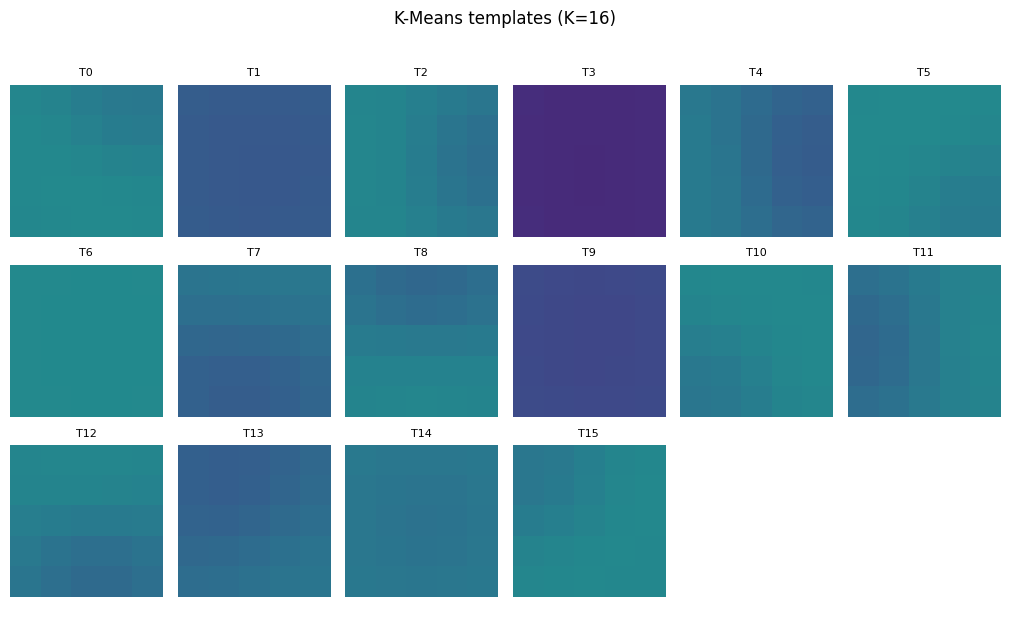

Saved templates (K=16) and template_meta.json


In [ ]:
# Save templates 
np.save(os.path.join(MODELS_DIR, "kmeans_templates.npy"), templates)
joblib.dump(kmeans, os.path.join(MODELS_DIR, "kmeans_model.joblib"))
with open(os.path.join(MODELS_DIR, "template_meta.json"), 'w') as f:
    json.dump({'K': int(FINAL_K), 'patch_size': int(PATCH_SINGLE),
               'source': 'LBPW patches from train lesions only',
               'n_patches': int(all_patches.shape[0]),
               'selection': 'aggregate positive mass-bg diff across all train images',
               'k_candidates': K_CANDIDATES,
               'value_mean': float(tf.mean())}, f, indent=2)

# Visualise templates
ncol = min(FINAL_K, 6); nrow = int(np.ceil(FINAL_K/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(1.7*ncol, 2*nrow))
axes = np.atleast_1d(axes).ravel()
for i in range(FINAL_K):
    axes[i].imshow(templates[i], cmap='viridis', vmin=0, vmax=1)
    axes[i].set_title(f"T{i}", fontsize=8); axes[i].axis('off')
for i in range(FINAL_K, len(axes)): axes[i].axis('off')
plt.suptitle(f"K-Means templates (K={FINAL_K})", y=1.02); plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section7_templates.png"), dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved templates (K={FINAL_K}) and template_meta.json")

In [ ]:
# Verification
def verify_section58():
    checks = {
        "Layer 1 all scales"     : all(len(layer1_maps[ps]) == len(final_df_loaded)
                                       for ps in PATCH_SIZES),
        "Layer 1 saved"          : all(os.path.exists(os.path.join(
                                       OUTPUTS_DIR, f"layer1_ms_lipw_{ps}x{ps}.npz"))
                                       for ps in PATCH_SIZES),
        "Split lesion-grouped"   : not (set(json.load(open(os.path.join(
                                       RESULTS_DIR,"train_test_split.json")))['train_lesions'])
                                       & set(json.load(open(os.path.join(
                                       RESULTS_DIR,"train_test_split.json")))['test_lesions'])),
        "Templates saved"        : os.path.exists(os.path.join(MODELS_DIR, "kmeans_templates.npy")),
        "K recorded == array"    : json.load(open(os.path.join(MODELS_DIR,
                                     "template_meta.json")))['K'] == templates.shape[0],
        "Templates discriminate" : n_used > 2,
    }
    print("=" * 52); print("SECTIONS 5-8 VERIFICATION"); print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}"); ok = ok and v
    print("=" * 52)
    print("Proceed to notebook 5." if ok else "Review failures.")
    return ok

verify_section58()

SECTIONS 5-8 VERIFICATION
  OK   Layer 1 all scales
  OK   Layer 1 saved
  OK   Split lesion-grouped
  OK   Templates saved
  OK   K recorded == array
  OK   Templates discriminate
Proceed to notebook 5.


True